---
title: The Maximal Coverage Location Problem (MCLP)
image: image.png
toc: true
execute: 
  enabled: true
---

The maximal location covering problem tries to optimize for a different objective to p-median and p-center and their variants. 

In p-median, we are trying to minimize the weighted travel time - so we care about the average time people will travel to get to a site. 

In p-center, we are trying to minimize the maximum travel time - so we'll potentially accept a slightly longer travel time on average if it means that

In MCLP, we are trying to maximise the number of regions that are within a given distance or travel time. 

For example, let's imagine we have 100 LSOAs in our problem, and we've calculated the travel time from each LSOA centroid to the possible sites.

Like with other problems, we'll work out the closest site to each LSOA for any given combination of sites. 

However, rather than just taking this travel time and using it for calculating an average or a maximum, we'll instead check it against a defined number - say 10 minutes. 

If the travel time from that LSOA to its nearest site in this configuration is less than 10 minutes, we'll record a 1. 

If the travel time is instead greater than or equal to 10 minutes, we'll record a 0. 

We then do this for every LSOA. At the end, we count up the number of 1's. 

Let's say 64 of our LSOAs were within 10 minutes of a site. 
We know that we have 100 LSOAs in total, so our output value is 0.64, or 64%. 

We might have a different solution where 68 of the LSOAs are within 10 minutes of a site. This could well have a worse average or maximum travel time - but if we're solving the MCLP, we'd rank the solution with the higher number of LSOAs within our travel time or distance threshold as a better solution regardless of the other metrics. 

Let's now try solving one of these problems. 

For the maximal location covering problem, we can set up our problem just like before.

In [1]:
from lokigi.site import SiteProblem

problem = SiteProblem()

problem.add_sites(
    "../../../sample_data/brighton_sites_named.geojson",
    candidate_id_col="site"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving_named.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )

problem.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

When we go to solve, we change our objective to "mclp".

We also need to pass in a new parameter - a 'threshold_for_coverage'. 

This is a value in the same units as our travel matrix that represents the threshold we care about. 

:::{.callout-note}
In this case, our travel matrix is in minutes, so we'd interpret this as us being interested in maximising the number of regions where people are within 10 **minutes** of a site. 

If our travel matrix was instead looking at the number of miles, the value we pass in to this argument wouldn't change - just our interpretation of it. 
:::

In [2]:
solutions = problem.solve(
    objectives="mclp",
    p=3,
    threshold_for_coverage=10
    )

  0%|          | 0/20 [00:00<?, ?it/s]

We can now see our solutions, paying particular attention to the column 'proportion_within_coverage_threshold'. 

:::{.callout-note}
If two solution shave the same 'proportion_within_coverage_threshold' value, like in this example, ties will be broken by ordering by the weighted average travel time. Note that if you haven't provided demand, the demand will be assumed to be equal across all regions, so weighted_average=unweighted_average in that context. 
:::

In [3]:
solutions.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,None,"[2, 3, 5]",10,5.36,5.36,8.06,16.69,0.95,LSOA L...
1,None,"[2, 3, 4]",10,5.45,5.45,8.50,16.69,0.95,LSOA L...
2,None,"[1, 2, 3]",10,5.59,5.59,9.00,16.69,0.94,LSOA L...
3,None,"[0, 2, 5]",10,6.21,6.21,9.33,16.69,0.94,LSOA L...
4,None,"[0, 2, 3]",10,5.67,5.67,9.36,16.69,0.93,LSOA L...
5,None,"[2, 4, 5]",10,6.29,6.29,9.26,16.69,0.93,LSOA L...
6,None,"[1, 2, 5]",10,6.31,6.31,9.45,16.69,0.92,LSOA L...
7,None,"[0, 2, 4]",10,6.32,6.32,9.70,16.69,0.91,LSOA L...
8,None,"[0, 1, 2]",10,6.39,6.39,9.77,16.69,0.91,LSOA L...
9,None,"[1, 3, 4]",10,6.76,6.76,11.32,21.71,0.83,LSOA L...


Let's have a quick look at what the underlying data looks like for the best solution. We can see that there is a 'within_threshold' column with values of True (1) and False (0). 

In [4]:
solutions.show_solutions()["problem_df"][0]

,LSOA,LSOA_x,Tulip (Site 3),Daisy (Site 4),Snowdrop (Site 6),min_cost,selected_site,within_threshold,LSOA_y,n
0,Brighton and Hove 027E,Brighton and Hove 027E,7.404833,8.197500,9.248500,7.404833,Tulip (Site 3),True,Brighton and Hove 027E,1
1,Brighton and Hove 027F,Brighton and Hove 027F,8.626167,9.351167,8.972833,8.626167,Tulip (Site 3),True,Brighton and Hove 027F,1
2,Brighton and Hove 027A,Brighton and Hove 027A,8.633000,6.840000,9.289167,6.840000,Daisy (Site 4),True,Brighton and Hove 027A,1
3,Brighton and Hove 029E,Brighton and Hove 029E,11.006000,6.328667,9.293000,6.328667,Daisy (Site 4),True,Brighton and Hove 029E,1
4,Brighton and Hove 029D,Brighton and Hove 029D,10.970000,5.216667,9.508500,5.216667,Daisy (Site 4),True,Brighton and Hove 029D,1
...,...,...,...,...,...,...,...,...,...,...
160,Brighton and Hove 012A,Brighton and Hove 012A,18.468500,8.652667,7.463000,7.463000,Snowdrop (Site 6),True,Brighton and Hove 012A,1
161,Brighton and Hove 005C,Brighton and Hove 005C,16.804000,9.490000,5.798500,5.798500,Snowdrop (Site 6),True,Brighton and Hove 005C,1
162,Brighton and Hove 012B,Brighton and Hove 012B,18.876667,8.952500,7.871000,7.871000,Snowdrop (Site 6),True,Brighton and Hove 012B,1
163,Brighton and Hove 005A,Brighton and Hove 005A,18.432167,11.068500,7.426667,7.426667,Snowdrop (Site 6),True,Brighton and Hove 005A,1


Let's now plot our best combination.

Note that the plot title automatically updates to include the coverage. 

:::{.callout-tip}
If we are working in a Jupyter notebook, we can prevent any additional output displaying from the mapping functions by ending our code with a semicolon.
:::

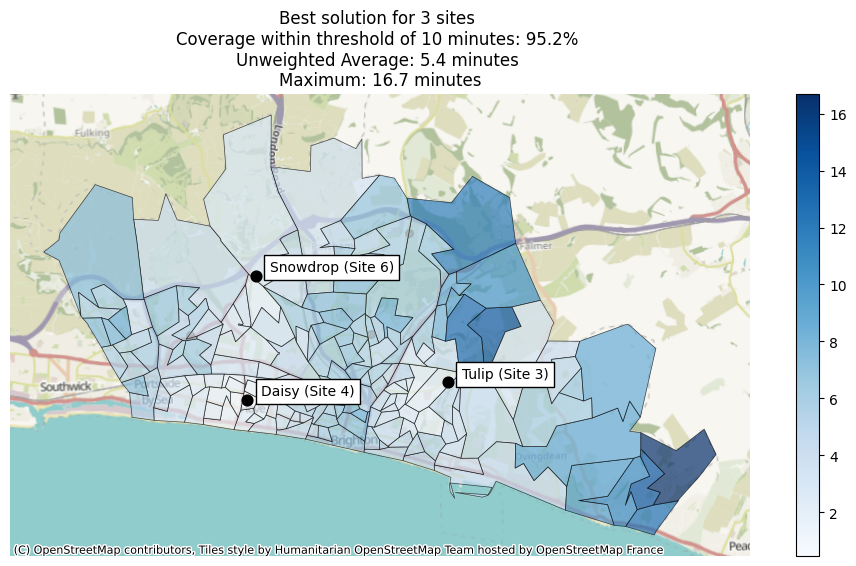

In [5]:
solutions.plot_best_combination();

Let's take a quick look at which regions have been allocated to each site in our best solution. 

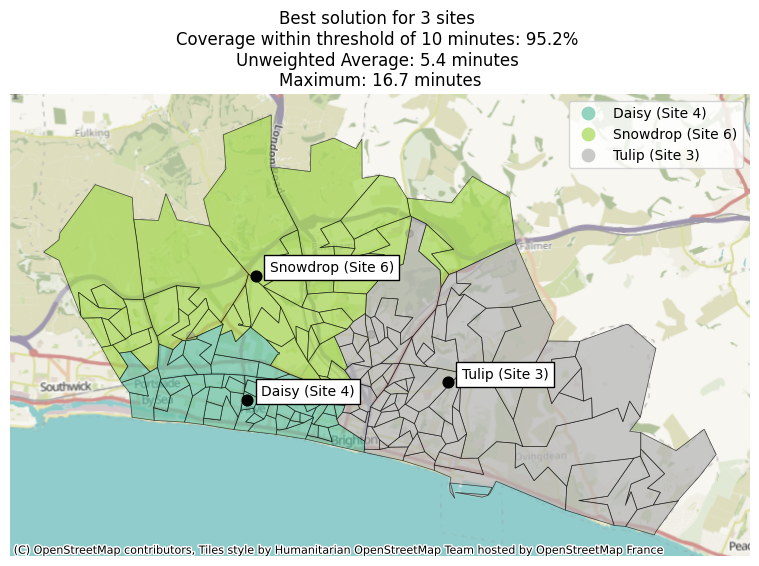

In [6]:
solutions.plot_best_combination(plot_site_allocation=True);

As we've set a threshold, we can now do a new type of plot, where we can colour each region by whether or not it meets the threshold we've defined. 

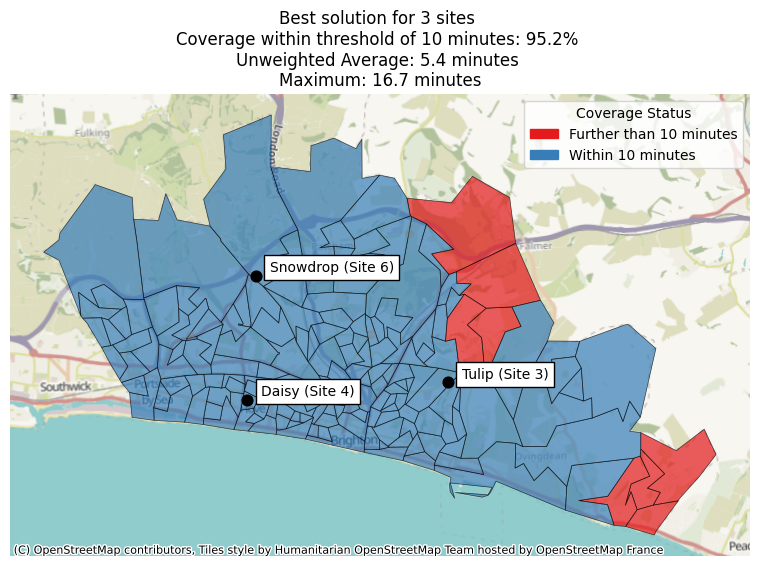

In [7]:
solutions.plot_best_combination(plot_regions_not_meeting_threshold=True);

Let's now plot the weighted travel time for the best 10 combinations. 

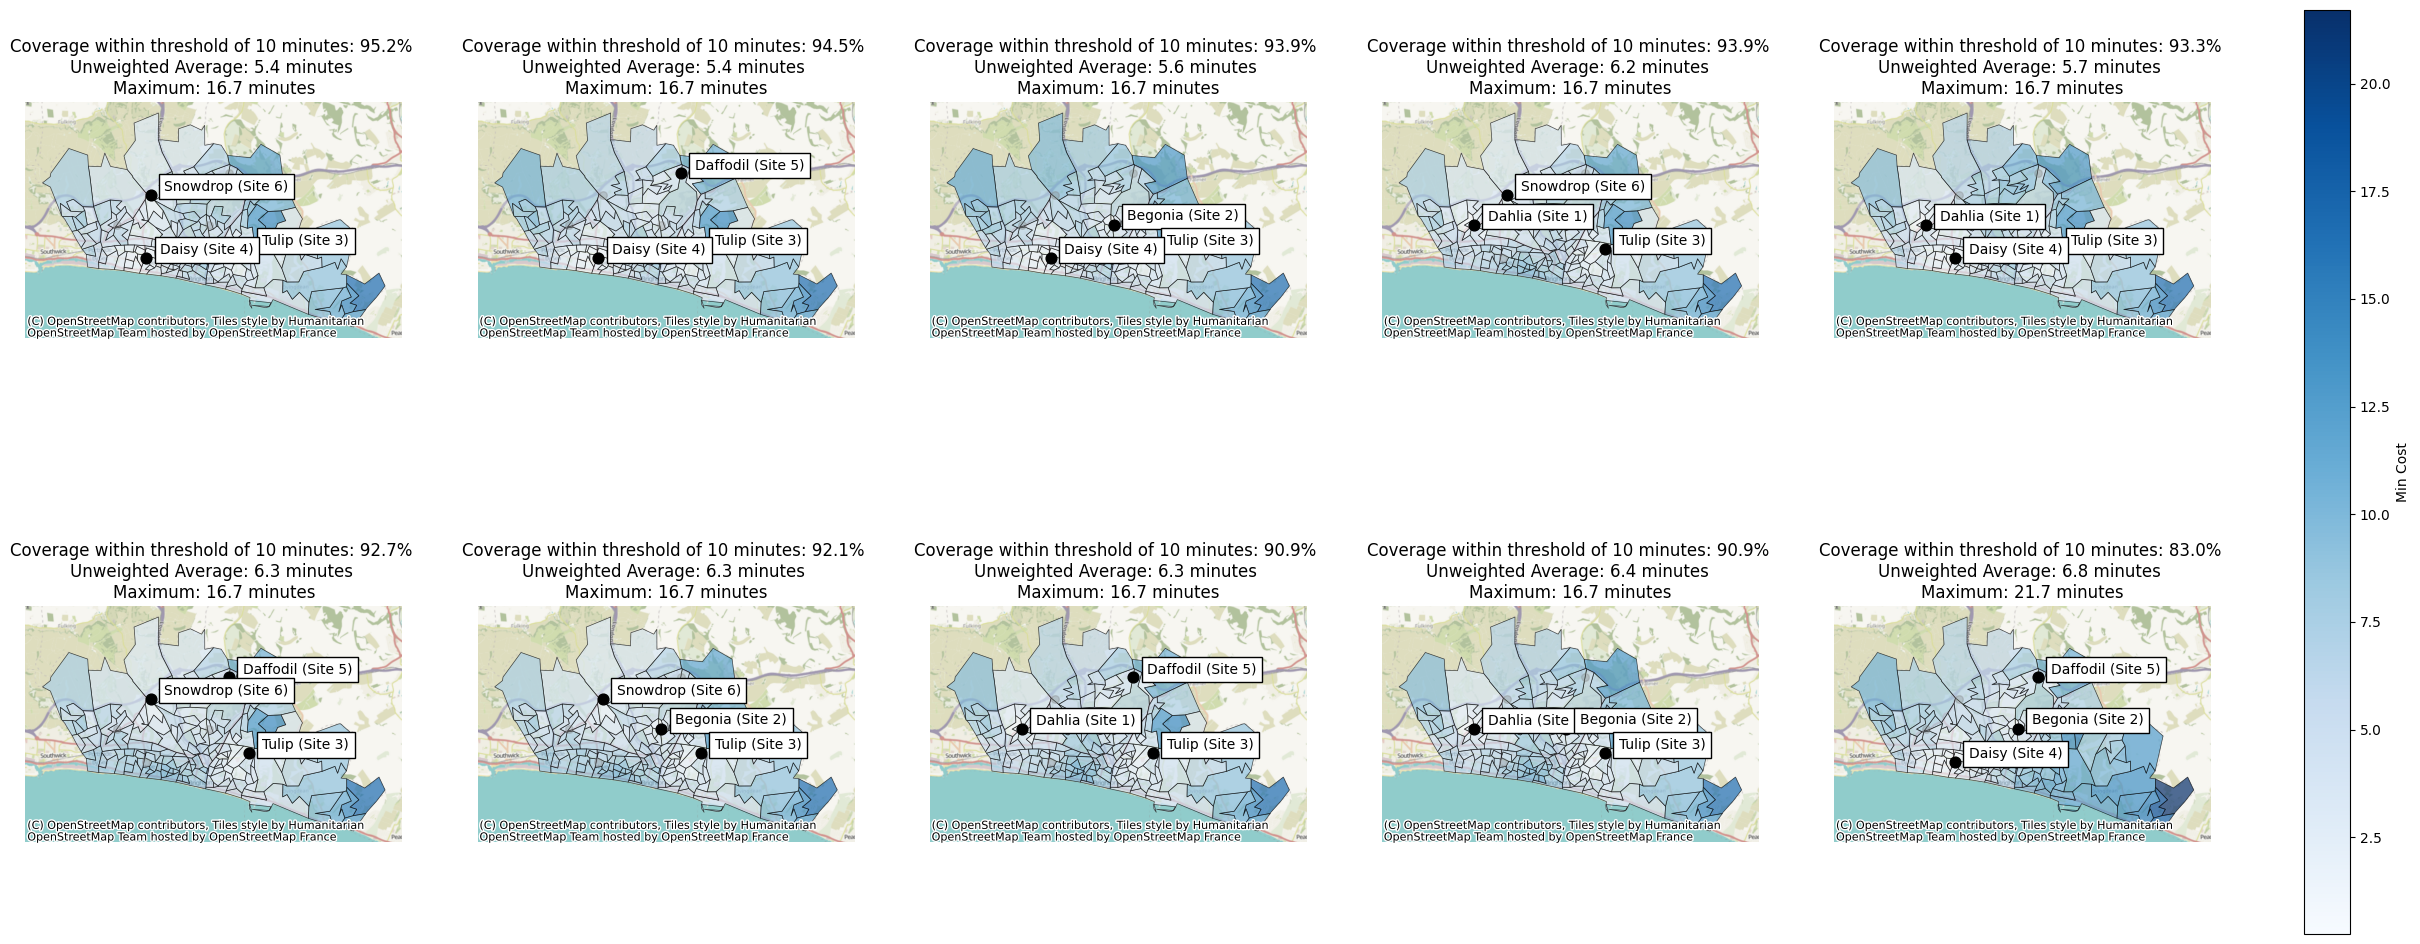

In [8]:
solutions.plot_n_best_combinations();

We can also use the `plot_regions_not_meeting_threshold` parameter in the `.plot_n_best_combinations` method. 

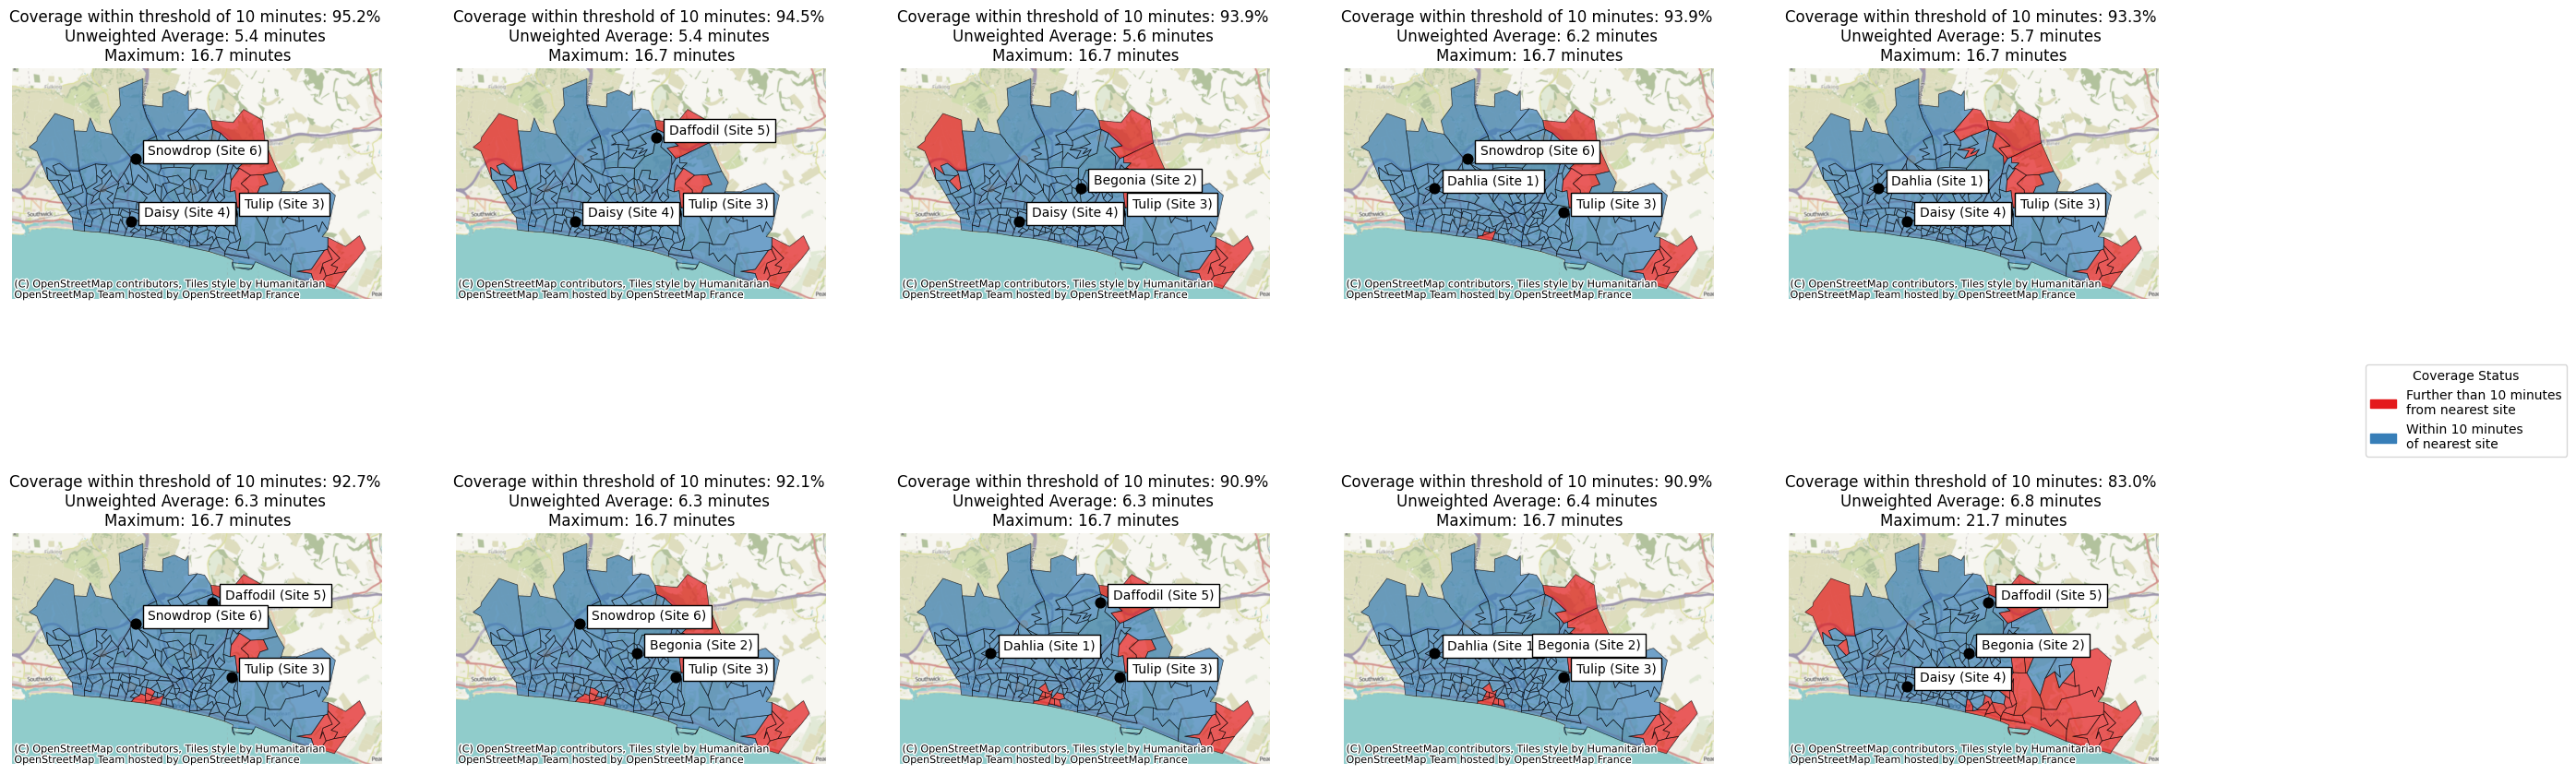

In [9]:
solutions.plot_n_best_combinations(plot_regions_not_meeting_threshold=True);

We may also want to plot the pareto fronts to compare trade-offs with coverage. 

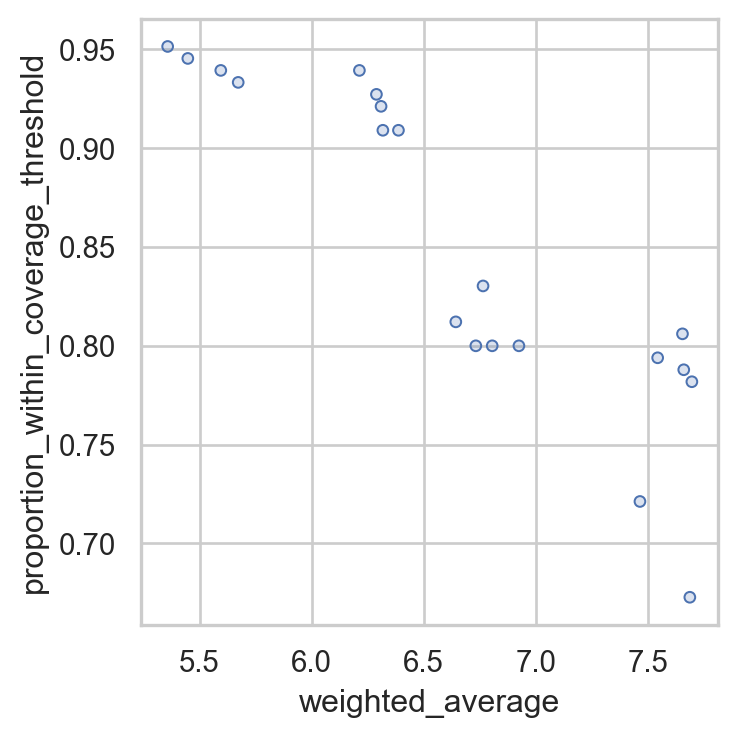

In [10]:
solutions.plot_simple_pareto_front("weighted_average", "proportion_within_coverage_threshold")

In this case, the best solution for coverage is also the best solution for weighted average travel time, so there is no line indicating a pareto front plotted as there is no trade-off to be made in this instance. We want to maximise the proportion within coverage threshold and minimize the weighted average travel time, so the point in the top left hand corner of this plot is the best at both. 

However, we can see that there is significant variation in weighted travel time across the 9 solutions that exceed 90% coverage within 10 minutes - so it's definitely worth being mindful of that when suggesting solutions to our stakeholders! 